In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


% mujeres que sobrevivieron: 0.7420382165605095
% hombres que sobrevivieron: 0.18890814558058924


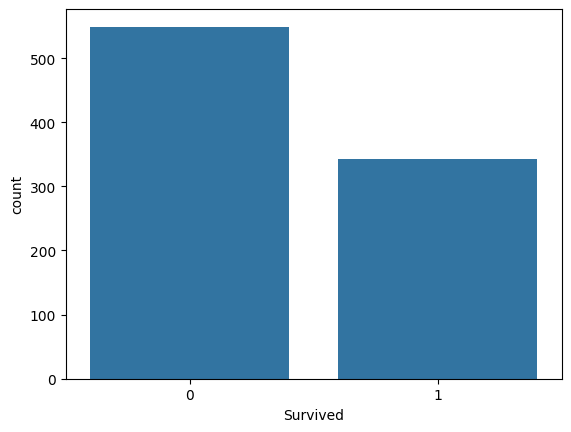

In [2]:
women = train_data.loc[train_data.Sex == 'female', "Survived"]
men = train_data.loc[train_data.Sex == 'male', "Survived"]

print("% mujeres que sobrevivieron:", women.mean())
print("% hombres que sobrevivieron:", men.mean())

sns.countplot(x="Survived", data=train_data)
plt.show()

In [3]:
y = train_data["Survived"]

features = ["Pclass", "Sex", "SibSp", "Parch"]

X = pd.get_dummies(train_data[features], drop_first=True)
X_test = pd.get_dummies(test_data[features], drop_first=True)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [4]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0],
    'Odds Ratio': np.exp(log_model.coef_[0])
})
coefficients

,Feature,Coefficient,Odds Ratio
0,Pclass,-0.722896,0.485345
1,SibSp,-0.274844,0.759690
2,Parch,-0.048841,0.952333
3,Sex_male,-1.291606,0.274829


In [5]:
y_val_probs = log_model.predict_proba(X_val_scaled)[:, 1]

def evaluate_threshold(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Threshold: {threshold}")
    print("Confusion Matrix:\n", cm)
    print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}\n")

for t in [0.3, 0.5, 0.7]:
    evaluate_threshold(y_val, y_val_probs, threshold=t)

Threshold: 0.3
Confusion Matrix:
 [[72 33]
 [ 9 65]]
Precision: 0.66, Recall: 0.88, F1: 0.76

Threshold: 0.5
Confusion Matrix:
 [[90 15]
 [22 52]]
Precision: 0.78, Recall: 0.70, F1: 0.74

Threshold: 0.7
Confusion Matrix:
 [[101   4]
 [ 38  36]]
Precision: 0.90, Recall: 0.49, F1: 0.63



In [6]:
X_test_scaled = scaler.transform(X_test)

#threshold elegido = 0.5
test_probs = log_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_data.PassengerId,
    'Survived': test_pred
})
submission.to_csv('submission_logistic.csv', index=False)
print("Submission generada")

Submission generada


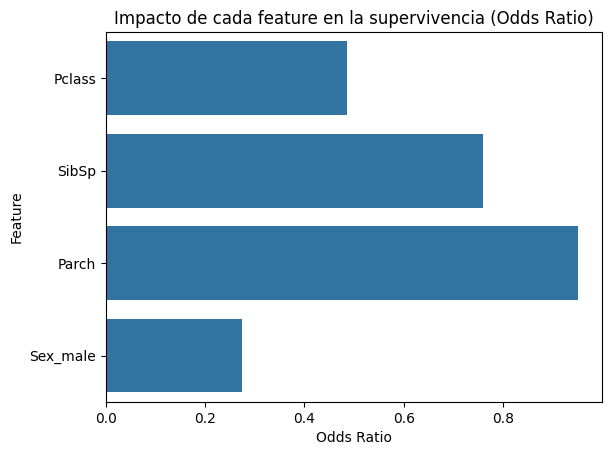

In [7]:
sns.barplot(x="Odds Ratio", y="Feature", data=coefficients)
plt.title("Impacto de cada feature en la supervivencia (Odds Ratio)")
plt.show()